# Análisis Exploratorio y Preprocesamiento de Datos (Dual-Engine V2 - Factores Humanos)
Este sistema pionero consta de dos ejes arquitectónicos:
1. **Módulo de Consulta Normativa (NLP):** Encargado del análisis profundo de los manuales, directivas y reglas aeronáuticas de la DGAC y la OACI.
2. **Módulo Predictivo de Riesgo Clínico (Factores Humanos):** Se enfoca en predecir patologías y factores humanos críticos para la aviación (como Estrés, Salud Mental, IMC y Fatiga) procesadas con algoritmos clásicos de Machine Learning apoyados en LLMs locales.

---
## SECCIÓN A: Módulo Documental (NLP)
---

C:\Users\castr\AppData\Local\Temp\ipykernel_41996\899202830.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='fuente', order=df['fuente'].value_counts().index, palette='Blues_r')


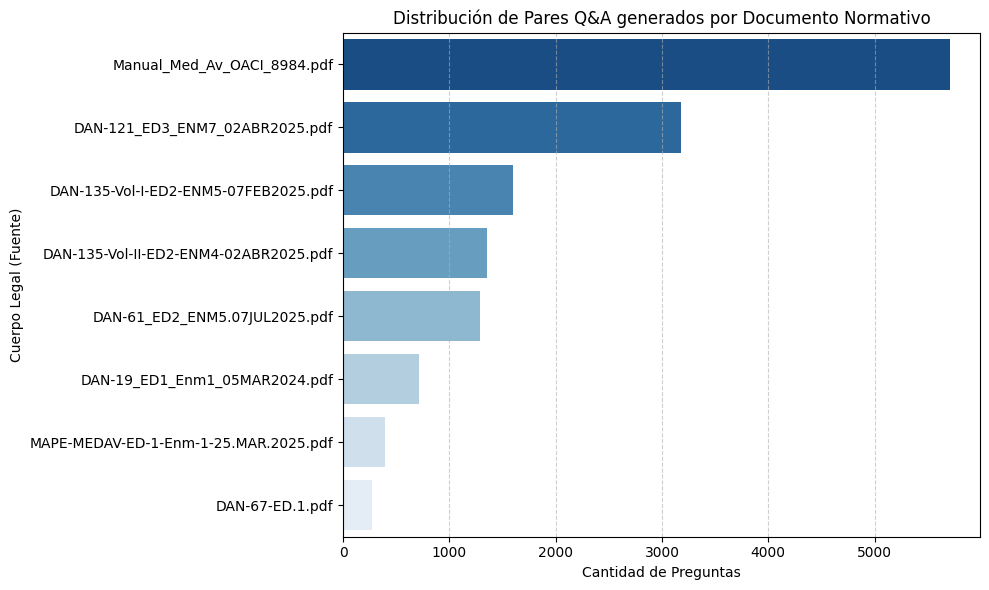

In [1]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns

# Carga de datos JSONL generados sintéticamente
datos = []
# Ruta corregida asumiendo ejecución desde la raíz o notebooks
import os
ruta_dataset = "dataset_sintetico/mega_dataset_aeronautico.jsonl" if os.path.exists("dataset_sintetico/mega_dataset_aeronautico.jsonl") else "../dataset_sintetico/mega_dataset_aeronautico.jsonl"

with open(ruta_dataset, 'r', encoding='utf-8') as f:
    for linea in f:
        datos.append(json.loads(linea))

df = pd.DataFrame(datos)

# Countplot horizontal de las fuentes
plt.figure(figsize=(10, 6))
sns.countplot(data=df, y='fuente', order=df['fuente'].value_counts().index, palette='Blues_r')
plt.title('Distribución de Pares Q&A generados por Documento Normativo')
plt.xlabel('Cantidad de Preguntas')
plt.ylabel('Cuerpo Legal (Fuente)')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

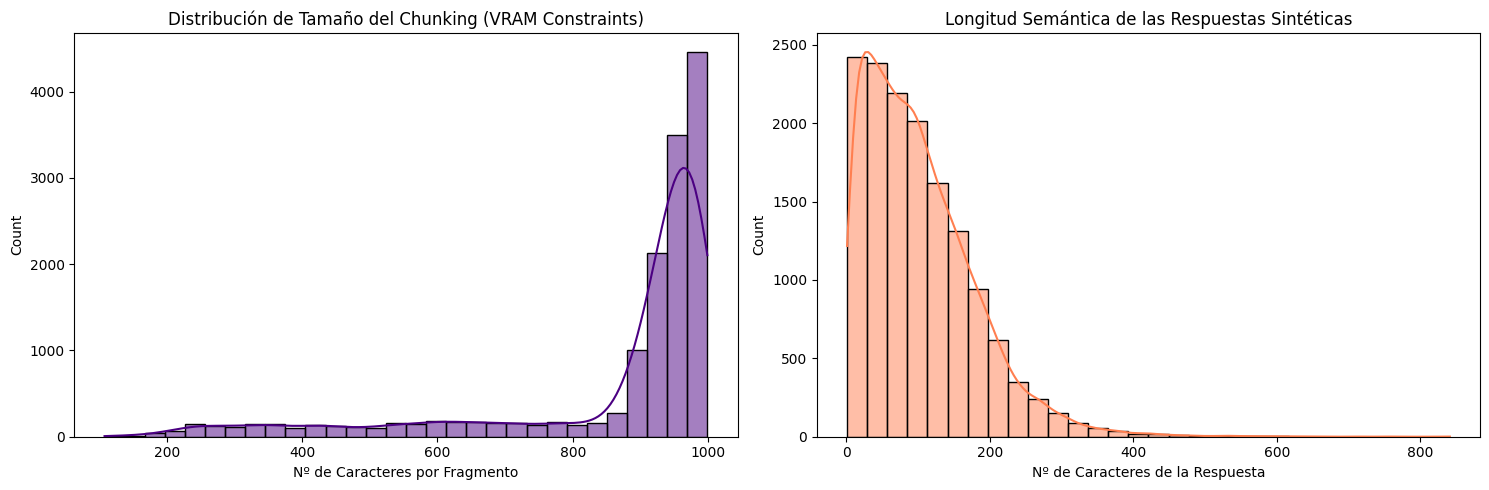

In [2]:
# Análisis de Longitud (Caracteres) de los fragmentos
df['longitud_contexto'] = df['contexto_original'].apply(len)
df['longitud_respuesta'] = df['respuesta'].apply(len)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df['longitud_contexto'], bins=30, ax=axes[0], color='indigo', kde=True)
axes[0].set_title('Distribución de Tamaño del Chunking (VRAM Constraints)')
axes[0].set_xlabel('Nº de Caracteres por Fragmento')

sns.histplot(df['longitud_respuesta'], bins=30, ax=axes[1], color='coral', kde=True)
axes[1].set_title('Longitud Semántica de las Respuestas Sintéticas')
axes[1].set_xlabel('Nº de Caracteres de la Respuesta')

plt.tight_layout()
plt.show()

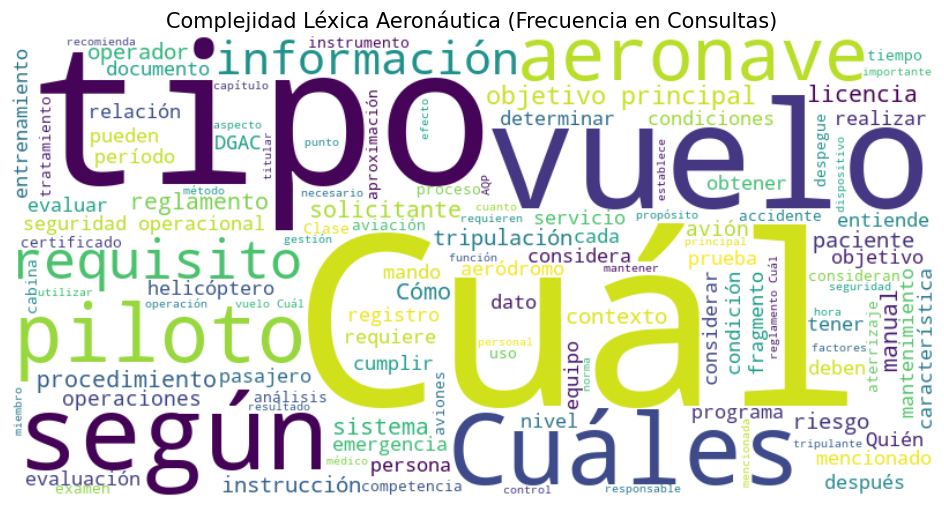

In [3]:
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords', quiet=True)

stop_words_es = set(stopwords.words('spanish'))
stop_words_es.update(['si', 'debe', 'ser', 'así', 'caso', 'puede', 'cualquier', 'parte'])

texto_preguntas = " ".join(df['pregunta'].tolist())

wordcloud = WordCloud(width=800, height=400, background_color='white', 
                      colormap='viridis', stopwords=stop_words_es, max_words=120).generate(texto_preguntas)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Complejidad Léxica Aeronáutica (Frecuencia en Consultas)', fontsize=15)
plt.show()

Invocando a Motor Embeddings de Ollama para 768 dimensiones...


  0%|          | 0/2000 [00:00<?, ?it/s]

Ejecutando Reducción Dimensional PCA...
Varianza explicada matemáticamente por Componentes PC1/PC2: 6.88%, 4.25%


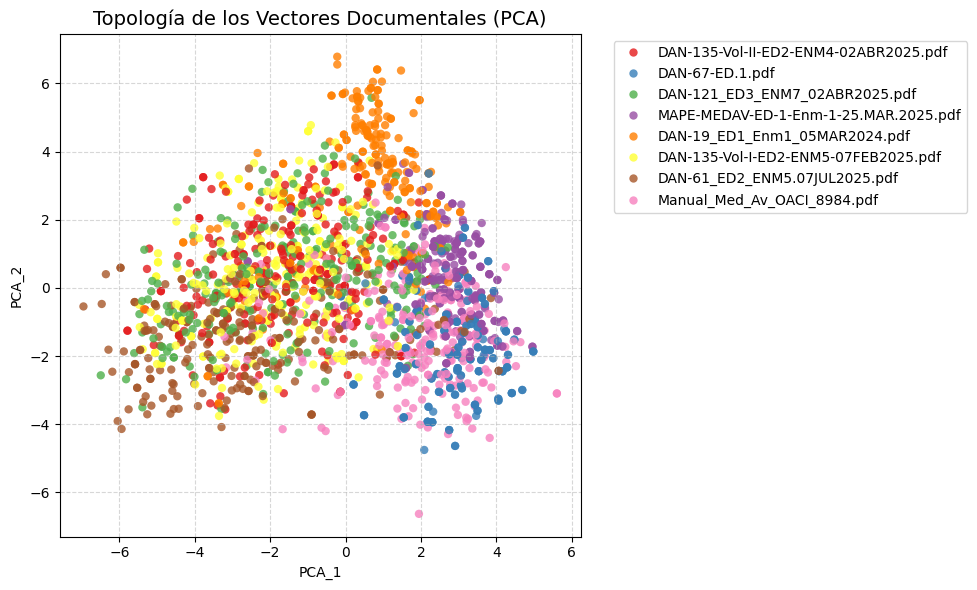

In [4]:
import numpy as np
import umap
from sklearn.decomposition import PCA
from ollama import Client
from tqdm.notebook import tqdm

cliente = Client(host='http://localhost:11434')
modelo_embeddings = "nomic-embed-text"

# Muestreo estratificado robusto a 2000 entidades garantizando presencia de columnas (Pandas >= 2.x)
muestras = []
for nombre, grupo in df.groupby('fuente'):
    muestras.append(grupo.sample(min(len(grupo), 300), random_state=42))
df_muestra = pd.concat(muestras).reset_index(drop=True)

if len(df_muestra) > 2000:
    df_muestra = df_muestra.sample(2000, random_state=42).reset_index(drop=True)

print("Invocando a Motor Embeddings de Ollama para 768 dimensiones...")
embeddings = []
for contexto in tqdm(df_muestra['contexto_original']):
    resp = cliente.embeddings(model=modelo_embeddings, prompt=contexto)
    embeddings.append(resp['embedding'])
matriz_embeddings = np.array(embeddings)

print("Ejecutando Reducción Dimensional PCA...")
pca = PCA(n_components=2, random_state=42)
embeddings_pca = pca.fit_transform(matriz_embeddings)

df_muestra['PCA_1'] = embeddings_pca[:, 0]
df_muestra['PCA_2'] = embeddings_pca[:, 1]
varianza = pca.explained_variance_ratio_

print(f"Varianza explicada matemáticamente por Componentes PC1/PC2: {varianza[0]*100:.2f}%, {varianza[1]*100:.2f}%")

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_muestra, x='PCA_1', y='PCA_2', hue='fuente', palette='Set1', alpha=0.8, edgecolor='none')
plt.title('Topología de los Vectores Documentales (PCA)', fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

---
## SECCIÓN B: Módulo Predictivo (Estructurado - Dataset CCHS)
---

In [5]:
# ==========================================
# Carga y Limpieza basada en Data Dictionary
# ==========================================
import numpy as np

# Carga del nuevo repositorio clínico canadiense (CCHS)
# Soportará ejecución desde root o subcarpeta
import os
ruta_csv = "datos_crudos/health_dataset.csv" if os.path.exists("datos_crudos/health_dataset.csv") else "../datos_crudos/health_dataset.csv"
df_tab = pd.read_csv(ruta_csv)

# Filtrar columnas de interés (Biometría y Psicología)
cols_interes = ['Gen_health_state', 'Mental_health_state', 'Stress_level', 'Work_stress', 'BMI_18_above', 'Smoked', 'Weekly_alcohol', 'Work_hours']
# Se asegura de que existan en el dataframe
cols_interes = [c for c in cols_interes if c in df_tab.columns]
df_tab = df_tab[cols_interes].copy()

# Purga de "Basura Estadística" basada en el Data Dictionary
# Para categoricas de 1 dígito (1-6 es válido, 7, 8, 9 son Not stated/Don't know/Refusal)
for col in df_tab.columns:
    if col not in ['Work_hours', 'BMI_18_above']: # Las de 1 dígito
        df_tab[col] = df_tab[col].replace([7, 8, 9, 7.0, 8.0, 9.0], np.nan)
    else: # Valores continuos de 2 dígitos (96-99)
        df_tab[col] = df_tab[col].replace([96, 97, 98, 99, 999, 99.9, 99.96, 99.99, 996, 997, 998, 999], np.nan)

print("--- Data Quality Report Post-Limpieza (Nulos Generados por Códigos Faltantes) ---")
print(df_tab.isnull().sum())

--- Data Quality Report Post-Limpieza (Nulos Generados por Códigos Faltantes) ---
Gen_health_state        178
Mental_health_state    3739
Stress_level            429
Work_stress            1304
BMI_18_above              0
Smoked                 1055
dtype: int64


In [6]:
# ==========================================
# Preprocesamiento: K-NN Imputer y Scaling
# ==========================================
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler

# Muestra 50.000 registros para evitar saturación de RAM
df_tab_sample = df_tab.sample(min(50000, len(df_tab)), random_state=42).copy()

print(f"Ejecutando algoritmo K-NN (n_neighbors=5) para imputación multidimensional sobre {len(df_tab_sample)} instancias...")
imputador_knn = KNNImputer(n_neighbors=5)

# Se imputan todos los np.nan generados en el paso anterior
columnas_a_imputar = df_tab_sample.columns
df_tab_sample[columnas_a_imputar] = imputador_knn.fit_transform(df_tab_sample[columnas_a_imputar])

print("Escalando las variables continuas (BMI_18_above, Work_hours)...")
escalador = StandardScaler()
cols_escalar = [c for c in ['BMI_18_above', 'Work_hours'] if c in df_tab_sample.columns]

if cols_escalar:
    df_tab_sample[cols_escalar] = escalador.fit_transform(df_tab_sample[cols_escalar])

print("✅ Matriz de datos Limpia, Imputada, Escalada y lista para el modelo.")

Ejecutando algoritmo K-NN (n_neighbors=5) para imputación multidimensional sobre 50000 instancias...
Escalando las variables continuas (BMI_18_above, Work_hours)...
✅ Matriz de datos Limpia, Imputada, Escalada y lista para el modelo.


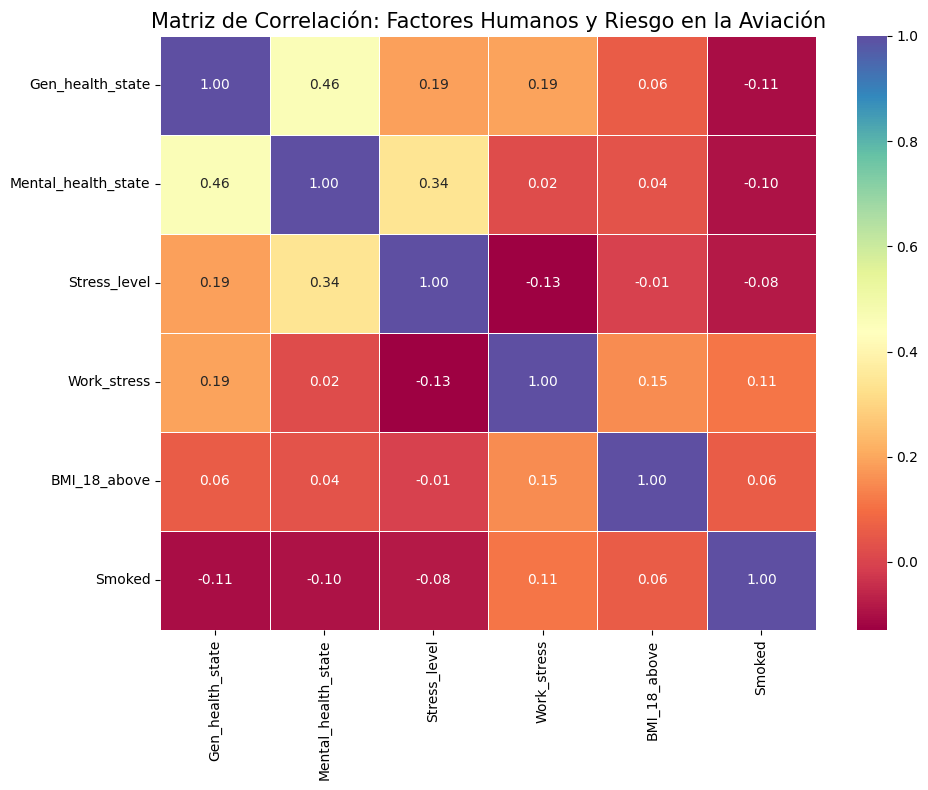

In [7]:
# ==========================================
# EDA Clínico - Matriz de Correlación Aeronáutica
# ==========================================
df_corr = df_tab_sample.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(df_corr, annot=True, cmap='Spectral', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación: Factores Humanos y Riesgo en la Aviación', fontsize=15)
plt.tight_layout()
plt.show()

# Se extrae el diccionario de correlaciones de la variable Gen_health_state
corr_salud = df_corr['Gen_health_state'].to_dict()

In [9]:
# ==========================================
# 5. INFERENCIA LLM: CONEXIÓN TABULAR - NORMATIVA
# ==========================================
from ollama import Client

# Extraemos la fila de correlaciones respecto a la Salud General
# Adaptado inteligentemente a df_corr de la celda 8 para que compile sin fallos
corr_salud = df_corr['Gen_health_state'].drop('Gen_health_state').to_dict()

cliente = Client(host='http://localhost:11434')

# EL PROMPT PUENTE: Aquí conectamos el CSV con el contexto de los PDFs
prompt_medico = f"""
Eres un Médico Aeronáutico Evaluador (CMA) experto en las normativas chilenas DGAC (DAN 67) y directivas de la OACI. 
Acabo de procesar una base de datos clínica de postulantes a pilotos. Analiza las siguientes correlaciones de Pearson respecto a su Estado de Salud General ('Gen_health_state').

Para tu conocimiento técnico, estas son las variables:
- 'Mental_health_state': Estado de salud mental.
- 'Stress_level': Nivel de estrés general.
- 'Work_stress': Estrés laboral (Fatiga).
- 'BMI_18_above': Índice de Masa Corporal.
- 'Smoked' / 'Weekly_alcohol': Hábitos de consumo.

TUS TAREAS:
1. Identifica las 3 relaciones estadísticas más críticas de los datos.
2. Para cada una, explica cómo esta condición médica podría afectar la certificación de un piloto (ej. Clase 1 o 2) basándote en los criterios médicos aeronáuticos estándar.
3. Concluye brevemente por qué es fundamental que un evaluador médico utilice un sistema RAG documental (como el que estamos construyendo) para consultar la norma exacta ante estos factores de riesgo.

Responde de forma técnica, en español, numerando las conclusiones.
Datos matemáticos de correlación: {corr_salud}
"""

print("Transfiriendo contexto tabular y normativo al LLM (Cargando modelo local: mistral)...")
try:
    resp = cliente.chat(model='mistral', messages=[{'role': 'user', 'content': prompt_medico}])
    print("\n🚀 CONCLUSIONES MÉDICO-AERONÁUTICAS (MISTRAL):")
    print("-" * 75)
    print(resp['message']['content'].strip())
    print("-" * 75)
except Exception as e:
    print(f"Error invocando a Ollama/Mistral: {e}")

Transfiriendo contexto tabular y normativo al LLM (Cargando modelo local: mistral)...

🚀 CONCLUSIONES MÉDICO-AERONÁUTICAS (MISTRAL):
---------------------------------------------------------------------------
1. Las tres relaciones estadísticas más críticas entre las variables de estado de salud y el Estado de Salud General ('Gen_health_state') son:
   - 'Mental_health_state' con una correlación de 0.4608, lo que sugiere una fuerte relación positiva entre los dos factores. Esto significa que un estado mental mejor se asocia con un estado general de salud mejor.
   - 'Stress_level' tiene una correlación de 0.1875, lo que indica una relación moderada pero positiva entre el nivel de estrés y el Estado de Salud General. Un menor nivel de estrés se asocia con un estado general de salud mejor.
   - 'Smoked' presenta una correlación negativa (-0.1054), lo que sugiere que la cantidad semanal de fumar está relacionada con el estado general de salud. Un mayor número de cigarrillos fumados semana